In [43]:
import os
import pickle
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [44]:
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

# ============================================
# SELECT YEAR FOR SUSCEPTIBILITY MAPPING
# ============================================

YEAR = 2022

RASTER_PATH = os.path.join(
    DATA_DIR,
    "processed",
    f"Mahanadi_Predictors_{YEAR}.tif"
)

print("Susceptibility mapping year:", YEAR)
print("Raster:", RASTER_PATH)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "random_forest_model.pkl"
)

DATASET_PATH = os.path.join(
    DATA_DIR,
    "processed",
    "Mahanadi_Riverbank_Erosion_2018_2024_ML_Ready.csv"
)

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Raster path:", RASTER_PATH)
print("Raster exists:", os.path.exists(RASTER_PATH))
print("Model exists:", os.path.exists(MODEL_PATH))
print("Dataset exists:", os.path.exists(DATASET_PATH))

Susceptibility mapping year: 2022
Raster: c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\data\processed\Mahanadi_Predictors_2022.tif
Raster path: c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\data\processed\Mahanadi_Predictors_2022.tif
Raster exists: True
Model exists: True
Dataset exists: True


In [45]:
with rasterio.open(RASTER_PATH) as src:

    print("Number of bands:", src.count)
    print("Raster width:", src.width)
    print("Raster height:", src.height)
    print("Coordinate reference system:", src.crs)
    print("Pixel size:", src.res)
    print("Bounds:", src.bounds)
    print("Data type:", src.dtypes)

Number of bands: 6
Raster width: 3898
Raster height: 2785
Coordinate reference system: EPSG:4326
Pixel size: (8.983152841195215e-05, 8.983152841195215e-05)
Bounds: BoundingBox(left=83.84991642958549, bottom=21.34998986308343, right=84.20007972733528, top=21.600170669710717)
Data type: ('float32', 'float32', 'float32', 'float32', 'float32', 'float32')


In [46]:
import joblib

rf_model = joblib.load(MODEL_PATH)

print("Model loaded successfully.")
print("Model type:", type(rf_model))
print("Number of features expected:", rf_model.n_features_in_)

c:\Users\salon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\salon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model loaded successfully.
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Number of features expected: 12


In [47]:
df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)

FEATURES = [
    "NDVI",
    "NDWI",
    "Elevation",
    "Rainfall",
    "LandCover",
    "Distance_From_River"
]

TARGET = "Label"

print("\nFeatures:")
print(FEATURES)

Dataset shape: (6000, 11)

Features:
['NDVI', 'NDWI', 'Elevation', 'Rainfall', 'LandCover', 'Distance_From_River']


In [48]:
train_df = df[df["Feature_Year"] <= 2021].copy()

print("Training rows:", len(train_df))

print("\nTraining feature years:")
print(sorted(train_df["Feature_Year"].unique()))

print("\nTraining label distribution:")
print(train_df["Label"].value_counts().sort_index())

Training rows: 4000

Training feature years:
[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Training label distribution:
Label
0    2000
1    2000
Name: count, dtype: int64


In [49]:
NUMERIC_FEATURES = [
    "NDVI",
    "NDWI",
    "Elevation",
    "Rainfall",
    "Distance_From_River"
]

CATEGORICAL_FEATURES = [
    "LandCover"
]

# Standardize numerical features
scaler = StandardScaler()

X_numeric_train = scaler.fit_transform(
    train_df[NUMERIC_FEATURES]
)

# One-hot encode LandCover
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_landcover_train = encoder.fit_transform(
    train_df[CATEGORICAL_FEATURES]
)

# Combine numerical + categorical features
X_train_processed = np.hstack([
    X_numeric_train,
    X_landcover_train
])

print("Processed training shape:", X_train_processed.shape)

print("\nLandCover categories:")
print(encoder.categories_)

Processed training shape: (4000, 12)

LandCover categories:
[array([0, 1, 3, 4, 5, 6, 7])]


In [50]:
landcover_categories = encoder.categories_[0]

processed_feature_names = (
    NUMERIC_FEATURES
    + [f"LandCover_{int(x)}" for x in landcover_categories]
)

print("Processed feature order:\n")

for i, feature in enumerate(processed_feature_names):
    print(f"{i}: {feature}")

print("\nTotal features:", len(processed_feature_names))

Processed feature order:

0: NDVI
1: NDWI
2: Elevation
3: Rainfall
4: Distance_From_River
5: LandCover_0
6: LandCover_1
7: LandCover_3
8: LandCover_4
9: LandCover_5
10: LandCover_6
11: LandCover_7

Total features: 12


In [51]:
print("Random Forest expects:", rf_model.n_features_in_, "features")
print("Our preprocessing creates:", len(processed_feature_names), "features")

if rf_model.n_features_in_ == len(processed_feature_names):
    print("✅ Feature count matches!")
else:
    print("❌ Feature count does not match!")

Random Forest expects: 12 features
Our preprocessing creates: 12 features
✅ Feature count matches!


In [52]:
OUTPUT_PROBABILITY = os.path.join(
    RESULTS_DIR,
    f"Mahanadi_Susceptibility_{YEAR}_Probability.tif"
)

with rasterio.open(RASTER_PATH) as src:

    profile = src.profile.copy()

    profile.update(
        count=1,
        dtype="float32",
        compress="lzw",
        nodata=-9999
    )

    with rasterio.open(
        OUTPUT_PROBABILITY,
        "w",
        **profile
    ) as dst:

        for _, window in src.block_windows(1):

            # Read the six predictor bands for this window
            data = src.read(
                indexes=[1, 2, 3, 4, 5, 6],
                window=window
            )

            rows = data.shape[1]
            cols = data.shape[2]

            # Convert:
            # bands × rows × cols
            # into:
            # pixels × bands

            pixels = data.reshape(
                data.shape[0],
                -1
            ).T

            # Identify valid pixels
            valid = np.all(
                np.isfinite(pixels),
                axis=1
            )

            probabilities = np.full(
                pixels.shape[0],
                -9999,
                dtype=np.float32
            )

            if np.any(valid):

                valid_pixels = pixels[valid]

                # Create dataframe with the six predictors
                raster_df = pd.DataFrame(
                    valid_pixels,
                    columns=[
                        "NDVI",
                        "NDWI",
                        "Elevation",
                        "Rainfall",
                        "LandCover",
                        "Distance_From_River"
                    ]
                )

                # Standardize numerical features
                numeric_data = scaler.transform(
                    raster_df[NUMERIC_FEATURES]
                )

                # One-hot encode LandCover
                landcover_data = encoder.transform(
                    raster_df[CATEGORICAL_FEATURES]
                )

                # Combine into 12 features
                processed_data = np.hstack([
                    numeric_data,
                    landcover_data
                ])

                # Predict probability of Potential Erosion
                pred_prob = rf_model.predict_proba(
                    processed_data
                )[:, 1]

                probabilities[valid] = pred_prob.astype(
                    np.float32
                )

            # Reshape back to raster block
            probabilities = probabilities.reshape(
                rows,
                cols
            )

            # Write the block
            dst.write(
                probabilities,
                1,
                window=window
            )

print(f"✅ {YEAR} susceptibility probability map created!")
print("Saved at:")
print(OUTPUT_PROBABILITY)

c:\Users\salon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\salon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\salon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\salon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\salon\AppData\Local\Programs\Python\Python311\Lib\site-packages\skl

✅ 2022 susceptibility probability map created!
Saved at:
c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\results\Mahanadi_Susceptibility_2022_Probability.tif


c:\Users\salon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [53]:
with rasterio.open(OUTPUT_PROBABILITY) as src:
    probability = src.read(1)

valid_probability = probability[probability != -9999]

print("Minimum probability:", np.min(valid_probability))
print("Maximum probability:", np.max(valid_probability))
print("Mean probability:", np.mean(valid_probability))
print("Number of valid pixels:", len(valid_probability))

Minimum probability: 0.0
Maximum probability: 1.0
Mean probability: 0.027550494
Number of valid pixels: 10851536


In [54]:
OUTPUT_CLASSES = os.path.join(
    RESULTS_DIR,
    f"Mahanadi_Susceptibility_{YEAR}_Classes.tif"
)

with rasterio.open(OUTPUT_PROBABILITY) as src:
    probability = src.read(1)
    profile = src.profile.copy()

# Initialize with NoData
susceptibility = np.full(
    probability.shape,
    -9999,
    dtype=np.int16
)

valid = probability != -9999

# 5 susceptibility classes
susceptibility[valid & (probability < 0.20)] = 1
susceptibility[valid & (probability >= 0.20) & (probability < 0.40)] = 2
susceptibility[valid & (probability >= 0.40) & (probability < 0.60)] = 3
susceptibility[valid & (probability >= 0.60) & (probability < 0.80)] = 4
susceptibility[valid & (probability >= 0.80)] = 5

# Update raster metadata
profile.update(
    dtype=rasterio.int16,
    count=1,
    nodata=-9999
)

with rasterio.open(OUTPUT_CLASSES, "w", **profile) as dst:
    dst.write(susceptibility, 1)

print("✅ Susceptibility class map created!")
print("Saved at:", OUTPUT_CLASSES)

# Print class counts
unique, counts = np.unique(
    susceptibility[valid],
    return_counts=True
)

print("\nClass distribution:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count:,} pixels")

✅ Susceptibility class map created!
Saved at: c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\results\Mahanadi_Susceptibility_2022_Classes.tif

Class distribution:
Class 1: 10,598,471 pixels
Class 2: 34,308 pixels
Class 3: 26,400 pixels
Class 4: 45,519 pixels
Class 5: 146,838 pixels


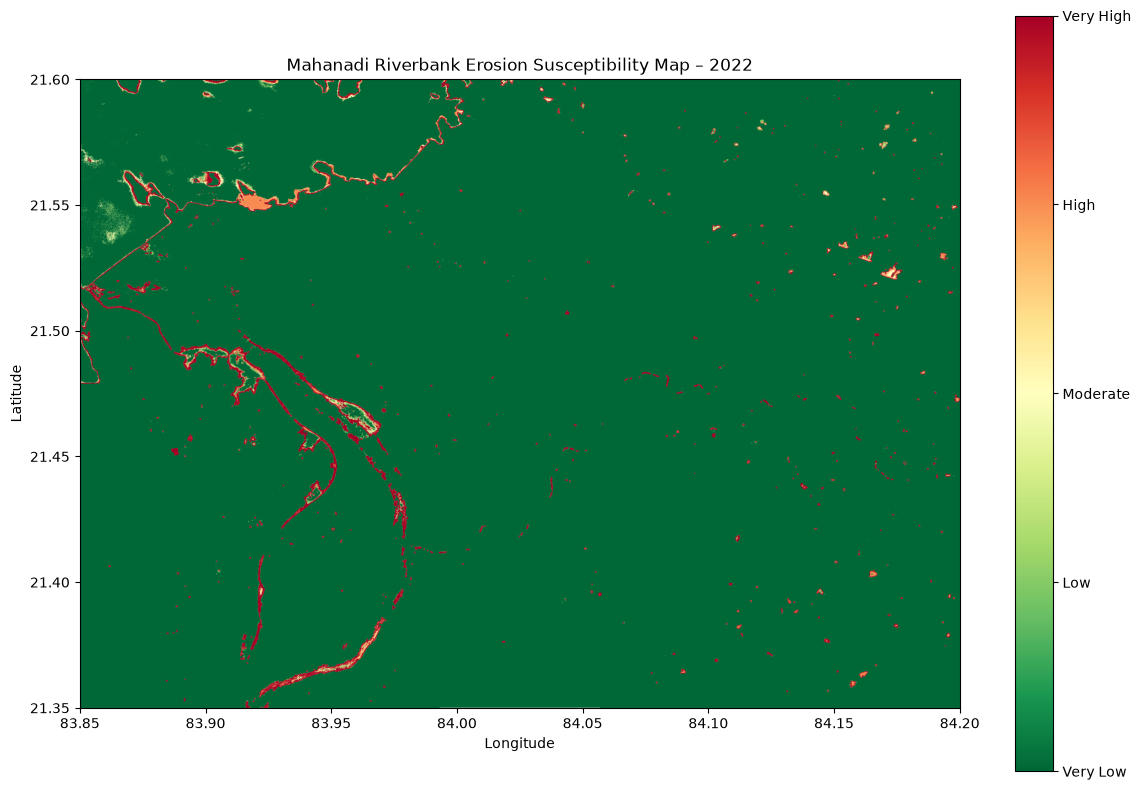

✅ Susceptibility map saved at:
c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\results\Mahanadi_Susceptibility_2022.png


In [55]:
OUTPUT_MAP = os.path.join(
    RESULTS_DIR,
    f"Mahanadi_Susceptibility_{YEAR}.png"
)

with rasterio.open(OUTPUT_CLASSES) as src:
    susceptibility = src.read(1)
    bounds = src.bounds

# Mask NoData
susceptibility_masked = np.ma.masked_where(
    susceptibility == -9999,
    susceptibility
)

plt.figure(figsize=(12, 8))

plt.imshow(
    susceptibility_masked,
    cmap="RdYlGn_r",
    vmin=1,
    vmax=5,
    extent=[
        bounds.left,
        bounds.right,
        bounds.bottom,
        bounds.top
    ]
)

cbar = plt.colorbar(
    ticks=[1, 2, 3, 4, 5]
)

cbar.ax.set_yticklabels([
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
])

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    f"Mahanadi Riverbank Erosion Susceptibility Map – {YEAR}"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_MAP,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Susceptibility map saved at:")
print(OUTPUT_MAP)